# kNN Architecture Testing on CIFAR-10 Dataset

A k-nearest neighbors model works by memorizing the locations of each datapoint. When an unseen datapoint is given for prediction, it looks at the k-nearest neighors of the unknown point and chooses the class with the highest frequency based on the neighbors.

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from pathlib import Path
from torchvision import datasets, transforms


SEED = 178
np.random.seed(SEED)

ROOT = Path.cwd().parent.parent
TRAIN_DIR = ROOT / "data" / "cifar10" / "train"
TEST_DIR = ROOT / "data" / "cifar10" / "test"
GRAPH_DIR = ROOT / "outputs" / "graphs"

# Overview
In this notebook, we will be training two models (kNN and kNN with PCA) and determine its accuracy on the CIFAR-10 Dataset. In this section, we will be training the kNN model with the aforementioned dataset and examine the metrics of the model.

In [12]:
transform = transforms.ToTensor()
train_set = datasets.CIFAR10(root=str(TRAIN_DIR), train=True, download=True, transform=transform)
test_set = datasets.CIFAR10(root=str(TEST_DIR), train=False, download=True, transform=transform)

X_train = train_set.data
y_train = np.array(train_set.targets)

X_test = test_set.data
y_test = np.array(test_set.targets)

# Reshape the data to be 2D (n_samples, n_features)
n_samples, n_rows, n_cols, n_channels = X_train.shape
X_train = X_train.reshape(n_samples, -1)

n_samples, n_rows, n_cols, n_channels = X_test.shape
X_test = X_test.reshape(n_samples, -1)

# Split the training data into a training set and a validation set
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=SEED)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)




Training set shape: (37500, 3072)
Validation set shape: (12500, 3072)
Test set shape: (10000, 3072)


# Understanding the data

In this notebook, we have conducted a training, validation, and test split with each set serving different purposes. The training set is utilized to fit the kNN models. Predictions will then be made using validation and hyperparameters would be finetuned to improve the accuracy on the validation set. Finally, the testing set will be used as final determination of the models' accuracy.

This notebook conducts **75/25 split on the training data**
| Set | % of data |
|---|---|
| Training | 62.5% |
| Validation | 20.8% |
| Testing | 16.7% |

Below two models are being trained: 
1. A Simple KNN classifier with `n_neighbors = 3`.
2. KNN classifier with Principal Component Analysis (PCA) with `n_components = 50` and `n_neighbors = 3`


In [14]:
# Model A
# Train the Simple KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Model B
# Train the KNN classifier with PCA
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)
knn_pca = KNeighborsClassifier(n_neighbors=3)
knn_pca.fit(X_train_pca, y_train)

# Display parameters of both models
print("Model A: Simple KNN")
print("Number of neighbors (k):", knn.n_neighbors)
print("\nModel B: KNN with PCA")
print("Number of neighbors (k):", knn_pca.n_neighbors)
print("Number of PCA components:", pca.n_components_)


Model A: Simple KNN
Number of neighbors (k): 3

Model B: KNN with PCA
Number of neighbors (k): 3
Number of PCA components: 50


# Why use Principal Component Analysis?

kNN models are known to struggle with high dimensionality as distances between all points become roughly uniform. This occurs because the available data becomes sparse in these high dimensions as the volume of space increases rapidly. This is known as the **curse of dimensionality** and affects distance-based models such as kNN. Principal Component Analysis reduces dimensionality by focusing on the axises with the largest variance. Later, in this notebook, we will investigate the results of PCA by comparing it with the base kNN model.

# Evaluating the Model A with Validation Set

Using the validation set, we will fine tuned the k nearest neighbors hyperparameter by testing the accuracies of different ks.

Model A - KNN with k=1: Validation Accuracy = 0.3330
Model A - KNN with k=3: Validation Accuracy = 0.3178
Model A - KNN with k=5: Validation Accuracy = 0.3251
Model A - KNN with k=7: Validation Accuracy = 0.3319
Model A - KNN with k=9: Validation Accuracy = 0.3254
Model A - KNN with k=11: Validation Accuracy = 0.3281
Best k value for Model A: 1 with Validation Accuracy = 0.3330


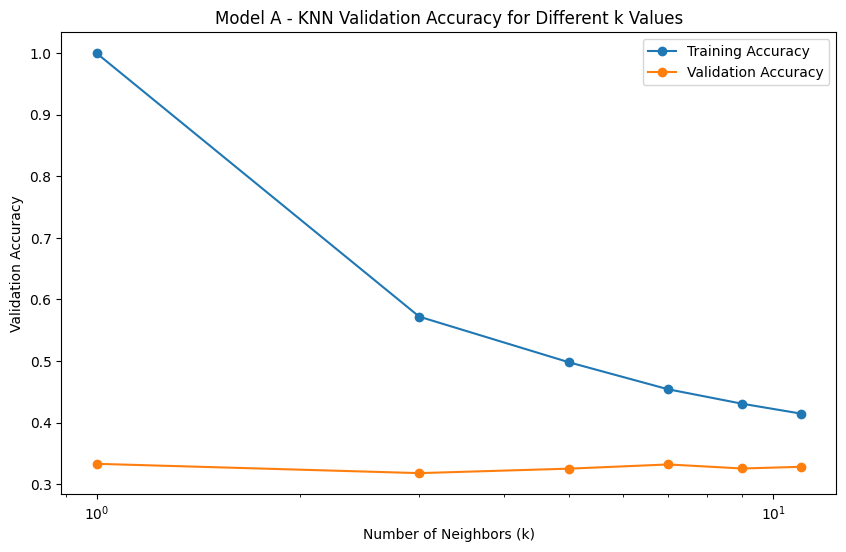

In [22]:
# Finetune model A k value
k_values = [1, 3, 5, 7, 9, 11]
best_k = None
best_accuracy = 0
train_accuracy_results = []
val_accuracy_results = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    y_train_pred = knn.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_accuracy_results.append(train_accuracy)
    
    y_val_pred = knn.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_accuracy_results.append(val_accuracy)
    
    print(f"Model A - KNN with k={k}: Validation Accuracy = {val_accuracy:.4f}")
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_k = k
    
print(f"Best k value for Model A: {best_k} with Validation Accuracy = {best_accuracy:.4f}")
    
        
# Plot validation accuracy for different k values
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracy_results, marker='o', label='Training Accuracy')
plt.plot(k_values, val_accuracy_results, marker='o', label='Validation Accuracy')
plt.title('Model A - KNN Validation Accuracy for Different k Values')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Validation Accuracy')
plt.xscale('log')
plt.legend()
# Output the graph to GRAPH_DIR
plt.savefig(GRAPH_DIR / "anishv2_model_a_knn_k_values.png")


As you can see, despite an optimized k value, the accuracy is approximately 33%. This is because CIFAR-10 dataset consists of 3072 dimensions which results in the kNN suffering from the curse of dimensionality. Looking at a confusion matrix and classification report can help us examine the issue. 

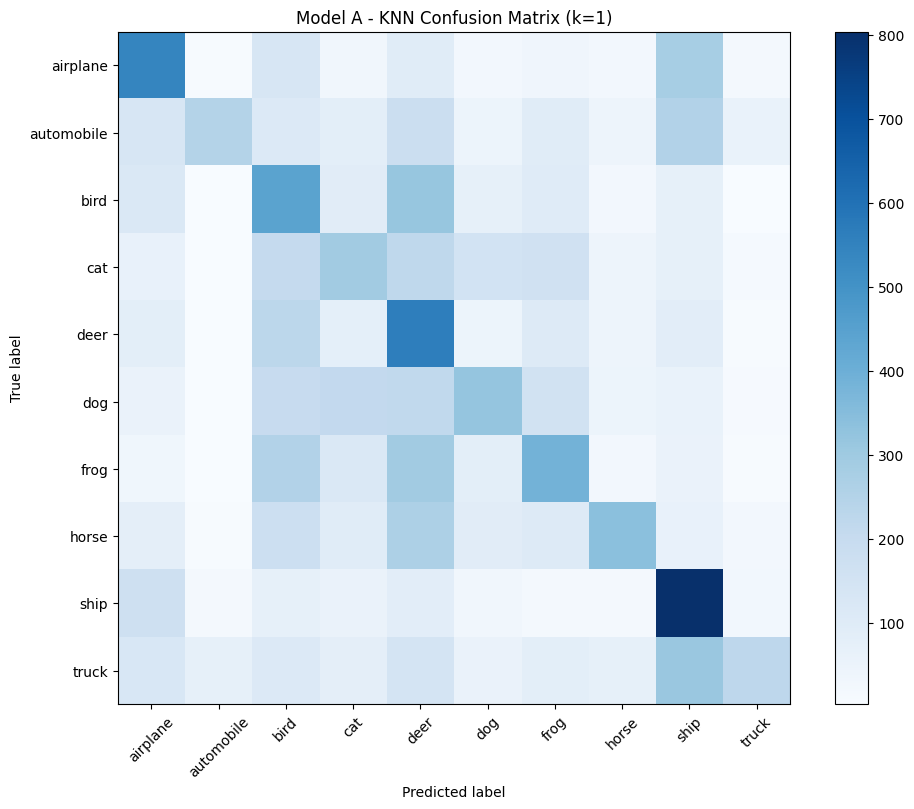

In [23]:
def plot_confusion_matrix(conf_matrix, classes, title='Confusion Matrix'):
    
    plt.figure(figsize=(10, 8))
    plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig(GRAPH_DIR / 'anishv2_model_a_knn_confusion_matrix.png')
    
    
    
    

# Best k value for Model A
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
# Confusion matrix 
y_val_pred = knn.predict(X_val)
conf_matrix = confusion_matrix(y_val, y_val_pred)
plot_confusion_matrix(conf_matrix, classes=train_set.classes, title=f'Model A - KNN Confusion Matrix (k={best_k})')


From this confusion matrix, we can see two major feature: the apparent bias towards ships and the cluster in the animal section. Since kNN is a distance-based models and relies on raw pixel values, the kNN can get distracted by characteristics such as background color instead of actual features (e.g. the bow of a ship). This is shown heavily in the ship row where truck, automobile, and airplane are being misclassified as ships due to their blue background color. 

This is further shown with cluster in the center which classifies animals. The kNN model cannot extract features of animals such as antlers for deers and relying heavily on color distribution due to pixel-wise distances. Since most animals follow a similar color distributions, the graph showcases a blurry cluster for animals.

In [25]:
# Display classification report for Model A
print(f"Classification Report for Model A - KNN (k={best_k}):")
print(classification_report(y_val, y_val_pred, target_names=train_set.classes))



Classification Report for Model A - KNN (k=1):
              precision    recall  f1-score   support

    airplane       0.39      0.45      0.42      1187
  automobile       0.66      0.20      0.31      1251
        bird       0.23      0.36      0.28      1240
         cat       0.26      0.24      0.25      1228
        deer       0.24      0.45      0.31      1244
         dog       0.35      0.25      0.29      1276
        frog       0.31      0.31      0.31      1252
       horse       0.51      0.27      0.36      1246
        ship       0.39      0.62      0.48      1301
       truck       0.56      0.18      0.27      1275

    accuracy                           0.33     12500
   macro avg       0.39      0.33      0.33     12500
weighted avg       0.39      0.33      0.33     12500



Looking at the classification report, we can see the same issue. We can see that the animal group has both low precision and recall reinstating the fact that the model is unable to extract characteristics of animals. For ship, with the high recall and low precisions, we can understand the model often characterizes images (high recall) likely due to the blue background, but does prediction that it is actually a ship is mostly incorrect (low precision). The inverse (high precision, low recall) is seen in car and truck as most of time it is being classified as ship, but when it is classified as the class it is mostly correct.

# Evaluating Model B with Validation Set